# Proyek Analisis Data: **Bike Sharing Dataset**
- **Nama:** Muhammad Fauzan
- **Email:** ojanmohmadin1701@gmail.com (Dicoding)
- **ID Dicoding:** muhfouza

## **Business Question** (Menentukan Pertanyaan Bisnis)

**Analisis Utama**
1. Bagaimana rata-rata jumlah penyewaan sepeda berubah berdasarkan kondisi cuaca selama periode 2011–2012?
2. Pada jam berapa rata-rata penyewaan sepeda mencapai puncaknya pada hari kerja dibandingkan dengan hari libur selama periode 2011–2012?"

**Analisis lanjutan**

3. Bagaimana perbedaan distribusi jumlah penyewaan sepeda antara pengguna casual dan registered berdasarkan jam dalam sehari selama periode 2011–2012?

## **Import Library** (Import Semua Packages/Library yang Digunakan)

In [30]:
%pip install pandas matplotlib seaborn streamlit

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Wrangling**

### 1 - Gathering Data

In [32]:
# load dataset
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")


In [33]:
# 5 data pertama day
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [34]:
# 5 data pertama hour
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset yang digunakan terdiri dari dua file yaitu day.csv dan hour.csv yang berisi informasi mengenai penyewaan sepeda.
- Dataset day.csv menyajikan data agregasi jumlah penyewaan sepeda per hari, sedangkan hour.csv menyajikan data penyewaan sepeda berdasarkan jam.
- Kedua dataset memiliki berbagai variabel seperti musim, kondisi cuaca, suhu, kelembapan, kecepatan angin, serta jumlah pengguna casual dan registered yang dapat digunakan untuk menganalisis pola penyewaan sepeda.

### 2 - Assessing Data

#### Cek Tipe Data

In [35]:
# Cek Tipe data - day.csv
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [36]:
# Cek Tipe Data - hour.csv
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Statistik Deskriptif

In [37]:
# Statistik Deskriptif - day.csv
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [38]:
# Statistik Deskriptif - hour.csv
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### Cek Missing Value

In [39]:
# Cek Missing Value - day.csv
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [40]:
# Cek Missing Value - hour.csv
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Cek Duplicate Data

In [41]:
print("Jumlah duplikasi day:", day_df.duplicated().sum())
print("Jumlah duplikasi hour:", hour_df.duplicated().sum())

Jumlah duplikasi day: 0
Jumlah duplikasi hour: 0


**Insight:**
- Dataset day.csv terdiri dari 731 baris data dengan 16 variabel, sedangkan dataset hour.csv terdiri dari 17.379 baris data dengan 17 variabel.
- Berdasarkan statistik deskriptif, rata-rata jumlah penyewaan sepeda per hari adalah sekitar 4504 sepeda dengan nilai maksimum mencapai 8714 sepeda.
- Jumlah pengguna registered memiliki rata-rata yang jauh lebih tinggi dibandingkan casual, yang menunjukkan bahwa sebagian besar pengguna bike sharing merupakan pelanggan terdaftar.
- Pada dataset hour.csv, rata-rata jumlah penyewaan sepeda per jam adalah sekitar 189 sepeda dengan nilai maksimum mencapai 977 sepeda.
- Variabel hr memiliki rentang nilai dari 0 hingga 23 yang menunjukkan bahwa data mencakup seluruh jam dalam satu hari sehingga memungkinkan analisis pola penggunaan sepeda berdasarkan waktu.
- Berdasarkan hasil pemeriksaan, tidak ditemukan missing values pada kedua dataset sehingga data dapat digunakan langsung untuk analisis.
- Tidak ditemukan data duplikat pada dataset sehingga tidak diperlukan proses penghapusan data.

### 3 - Cleaning Data

#### Convert Datetime

In [42]:
# Mengubah kolom tanggal menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])


In [43]:
# Verifikasi Cleaning - day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [44]:
# Verifikasi Cleaning - hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

#### Transformasi Season

In [45]:
# Transformasi Season
season_labels = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

day_df["season"] = day_df["season"].map(season_labels)
hour_df["season"] = hour_df["season"].map(season_labels)

#### Transformasi Weather

In [46]:
weather_labels = {
    1: "Clear",
    2: "Mist",
    3: "LightRain/Snow",
    4: "Heavy Rain/Snow"
}

day_df["weathersit"] = day_df["weathersit"].map(weather_labels)
hour_df["weathersit"] = hour_df["weathersit"].map(weather_labels)

#### Transformasi Weekday

In [47]:
weekday_labels = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

day_df["weekday"] = day_df["weekday"].map(weekday_labels)
hour_df["weekday"] = hour_df["weekday"].map(weekday_labels)

#### Cek Hasil Transformasi

In [48]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,Saturday,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,Sunday,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,Monday,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,Tuesday,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,Wednesday,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dilakukan konversi tipe data pada kolom `dteday` menjadi format datetime agar memudahkan analisis berbasis waktu.
- Beberapa variabel kategorikal seperti `season`, `weathersit`, dan `weekday` diubah dari kode numerik menjadi label kategori agar lebih mudah dipahami dalam proses analisis dan visualisasi data.

## **Exploratory Data Analysis** (EDA)

### EDA - Faktor yang mempengaruhi Penyewaan Sepeda

In [49]:
# 1 - Rata-rata penyewaan berdasarkan musim
day_df.groupby("season")["cnt"].mean().sort_values(ascending=False)

season
Fall      5644.303191
Summer    4992.331522
Winter    4728.162921
Spring    2604.132597
Name: cnt, dtype: float64

**Insight:**
- Berdasarkan analisis musim, jumlah penyewaan sepeda tertinggi terjadi pada musim Fall dengan rata-rata sekitar 5644 penyewaan per hari.
- Musim Spring memiliki rata-rata penyewaan terendah yaitu sekitar 2604, yang kemungkinan disebabkan oleh kondisi cuaca yang masih kurang mendukung untuk aktivitas bersepeda.

In [50]:
# 2 - Rata-rata penyewaan berdasarkan kondisi cuaca
day_df.groupby("weathersit")["cnt"].mean().sort_values(ascending=False)

weathersit
Clear             4876.786177
Mist              4035.862348
LightRain/Snow    1803.285714
Name: cnt, dtype: float64

**Insight:**
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.
- Cuaca cerah (Clear) memiliki rata-rata penyewaan tertinggi sekitar 4876 sepeda.
- Sebaliknya, pada kondisi Light Rain/Snow jumlah penyewaan turun drastis menjadi sekitar 1803 sepeda.
- Hal ini menunjukkan bahwa kondisi cuaca merupakan faktor penting dalam menentukan permintaan layanan bike sharing.

In [51]:
# 3 - Rata-rata penyewaan pada hari kerja vs bukan
day_df.groupby("workingday")["cnt"].mean().sort_values(ascending=False)

workingday
1    4584.820000
0    4330.168831
Name: cnt, dtype: float64

**Insight:**
- Jumlah penyewaan sepeda pada hari kerja sedikit lebih tinggi dibandingkan hari libur.
- Hal ini menunjukkan bahwa sepeda kemungkinan digunakan sebagai sarana transportasi untuk aktivitas sehari-hari seperti bekerja atau sekolah.

## **Visualization & Explanatory Analysis**

### Q-1: **Analisis Pengaruh Cuaca**

#### 1 - Visualisasi Pengaruh Cuaca

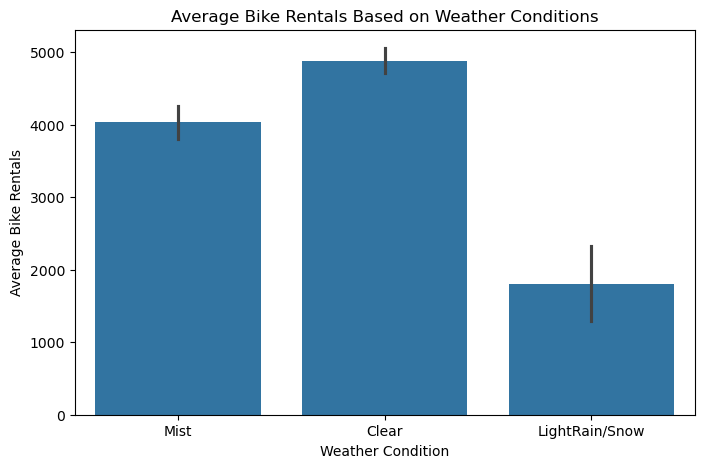

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    estimator=np.mean
)

plt.title("Average Bike Rentals Based on Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Average Bike Rentals")
plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa kondisi cuaca sangat mempengaruhi jumlah penyewaan sepeda. 
- Cuaca cerah menghasilkan jumlah penyewaan tertinggi, 
- sedangkan hujan atau salju ringan menyebabkan penurunan signifikan dalam penggunaan layanan bike sharing.

#### 2 - Explanatory Analysis Pengaruh Cuaca

**Bagaimana rata-rata jumlah penyewaan sepeda berubah berdasarkan kondisi cuaca selama periode 2011–2012?**
- Penyewaan sepeda tertinggi terjadi pada kondisi cuaca Clear.
- Ketika cuaca berubah menjadi Mist atau Light Rain/Snow, jumlah penyewaan menurun secara signifikan.
- Hal ini menunjukkan bahwa kondisi cuaca merupakan faktor penting yang mempengaruhi penggunaan layanan bike sharing.

### Q-2: **Analisis Rata-rata Penyewaan per Jam**

In [53]:
hourly_rentals = hour_df.groupby(["workingday","hr"])["cnt"].mean()
hourly_rentals

workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145

In [54]:
# membuat salinan dataframe agar tidak mengubah data asli
hour_plot_df = hour_df.copy()

# ubah label workingday
hour_plot_df["workingday"] = hour_plot_df["workingday"].map({
    0: "Holiday / Weekend",
    1: "Working Day"
})

#### 1 - Visualisasi Rata-rata Penyewaan per jam

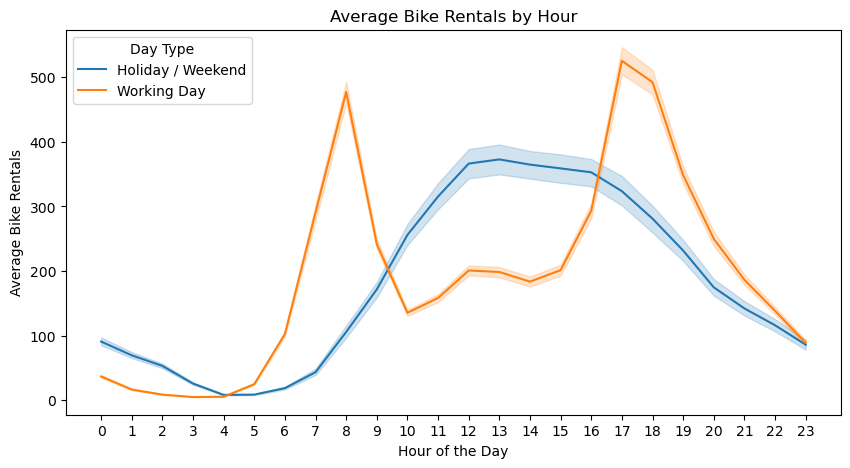

In [55]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hour_plot_df,
    x="hr",
    y="cnt",
    hue="workingday"
)

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Bike Rentals")
plt.legend(title="Day Type")
plt.xticks(range(0,24))

plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa jumlah penyewaan sepeda meningkat pada pagi hari dan mencapai puncaknya sekitar pukul 08.00. 
- Setelah itu jumlah penyewaan menurun pada siang hari dan kembali meningkat pada sore hari sekitar pukul 17.00 hingga 18.00. 
- Pola ini menunjukkan bahwa layanan bike sharing banyak digunakan sebagai sarana transportasi untuk aktivitas commuting seperti berangkat dan pulang kerja.

#### 2 - Explanatory Analysis Rata-rata Penyewaan per Jam

**Pada jam berapa rata-rata penyewaan sepeda mencapai puncaknya pada hari kerja dibandingkan dengan hari libur selama periode 2011–2012?**

- Penyewaan sepeda menunjukkan dua puncak aktivitas utama dalam sehari.
- Puncak pertama terjadi sekitar pukul 08.00 pagi.
- Puncak kedua terjadi sekitar pukul 17.00–18.00 sore.
- Pola ini menunjukkan bahwa banyak pengguna menggunakan sepeda untuk mobilitas kerja (commuting).

## **Analisis Lanjutan** (Opsional)

### Q-3: **Analisis Rata-rata Pengguna**

In [56]:
day_df[["casual","registered"]].mean()

casual         848.176471
registered    3656.172367
dtype: float64

#### 1 - Visualisasi Perbandingan User

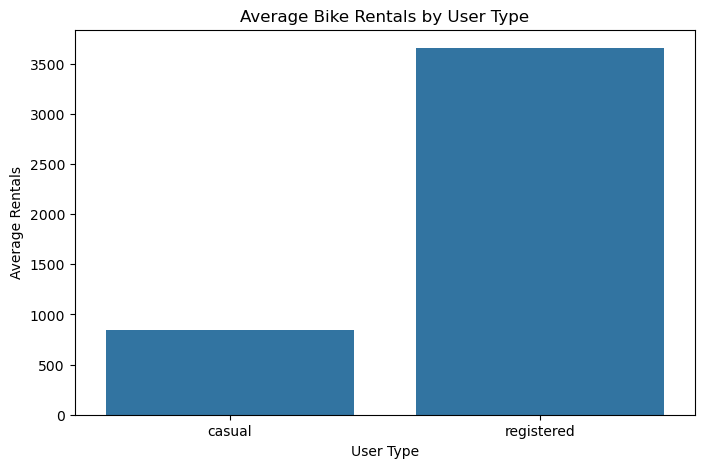

In [57]:
# Visualisasi Perbandingan User

plt.figure(figsize=(8,5))

avg_users = day_df[["casual","registered"]].mean()

sns.barplot(
    x=avg_users.index,
    y=avg_users.values
)

plt.title("Average Bike Rentals by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Rentals")
plt.show()

In [58]:
# Penggunaan Weekday vs Weekend
day_df.groupby("weekday")[["casual","registered"]].mean()

,casual,registered
weekday,,
Friday,752.288462,3938.000000
Monday,674.133333,3663.990476
Saturday,1465.257143,3085.285714
Sunday,1338.295238,2890.533333
Thursday,590.961538,4076.298077
Tuesday,556.182692,3954.480769
Wednesday,551.144231,3997.394231


**Insight:**
- Hasil analisis menunjukkan bahwa jumlah pengguna registered jauh lebih tinggi dibandingkan pengguna casual. Hal ini menunjukkan bahwa mayoritas pengguna layanan bike sharing merupakan pelanggan terdaftar yang kemungkinan menggunakan sepeda sebagai sarana transportasi rutin. 
- Sementara itu, pengguna casual cenderung lebih sedikit dan kemungkinan menggunakan sepeda untuk aktivitas rekreasi atau penggunaan sesekali.

#### 2 - Explanatory Analysis Rata-rata Pengguna

**Bagaimana perbedaan distribusi jumlah penyewaan sepeda antara pengguna casual dan registered berdasarkan jam dalam sehari selama periode 2011–2012?**
- Pengguna registered menunjukkan pola penggunaan yang stabil dan meningkat pada jam kerja.
- Pengguna casual cenderung lebih aktif pada siang hingga sore hari.
- Hal ini mengindikasikan bahwa pengguna casual lebih sering menggunakan sepeda untuk aktivitas rekreasi dibandingkan mobilitas rutin.

## **Conclusion**

Berdasarkan hasil analisis dataset Bike Sharing selama periode 2011–2012, diperoleh beberapa insight penting terkait pola penggunaan layanan penyewaan sepeda.
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. 
  - Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca Clear, sedangkan kondisi Light Rain/Snow menunjukkan jumlah penyewaan yang jauh lebih rendah. 
  - Hal ini menunjukkan bahwa pengguna cenderung menggunakan sepeda ketika kondisi cuaca mendukung aktivitas luar ruangan.
- Pola waktu penyewaan menunjukkan dua periode puncak aktivitas dalam sehari, yaitu: 
  - Sekitar pukul 08.00 pagi dan pukul 17.00–18.00 sore. 
  - Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas komuter seperti perjalanan menuju tempat kerja dan pulang kerja.
- Terdapat perbedaan perilaku penggunaan antara pengguna casual dan registered. 
  - Pengguna registered menunjukkan pola penggunaan yang lebih konsisten pada jam kerja, 
  - Pengguna casual cenderung lebih aktif pada siang hingga sore hari, yang kemungkinan berkaitan dengan aktivitas rekreasi atau wisata.

---

# Dataset untuk Dashboard

In [59]:
main_data = day_df.copy()
main_data.to_csv("dashboard/main_data.csv", index=False)

----